In [29]:
from bauer.models import RiskModelProbabilityDistortion, MagnitudeComparisonModel
import pandas as pd
import numpy as np
import seaborn as sns
from bauer.utils.math import softplus_np, logit_np, logistic
import scipy.stats as ss

In [99]:
model = RiskModelProbabilityDistortion(distort_magnitudes=True, distort_probabilities=True, p_grid_size=1000)

In [100]:
logistic(5.).eval()

array(0.9933072, dtype=float32)

In [105]:
parameters = {'probability_evidence_sd':.05, 'magnitude_evidence_sd':.05, 'magnitude_prior_sd':.25, 'probability_prior_sd':250., 'probability_prior_mu':-10.0}


paradigm = []
for p1 in [.1, .4, .55, .7, .9]:
    for p2 in [.5]:
        paradigm.append(pd.DataFrame({'p1':p1, 'p2':p2, 'n1':np.arange(1, 30,), 'n2':15., 'subject':1}))
        paradigm.append(pd.DataFrame({'p1':p1, 'p2':p2, 'n1':np.arange(1, 30,), 'n2':15., 'subject':2}))

paradigm = pd.concat(paradigm, axis=0, ignore_index=True).set_index('subject', append=True)


paradigm['ev1'] = paradigm['p1'] * paradigm['n1']
paradigm['ev2'] = paradigm['p2'] * paradigm['n2']

paradigm['log(ev2/ev1)'] = pd.cut(np.log(paradigm['ev2']/paradigm['ev1']), bins=10).transform(lambda x: x.mid)

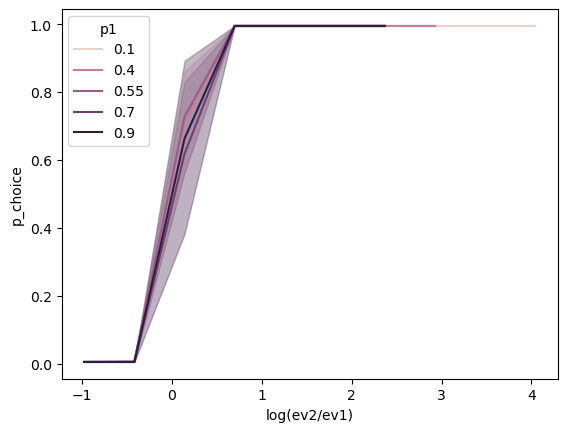

In [106]:
pred = model.predict(paradigm, parameters)

g = sns.lineplot(x='log(ev2/ev1)', y='p_choice', data=pred, hue='p1', legend=True)
# g = sns.lineplot(x='log(ev2/ev1)', y='p_choice', data=pred, hue='p2', legend=True)
# g.add_legend()

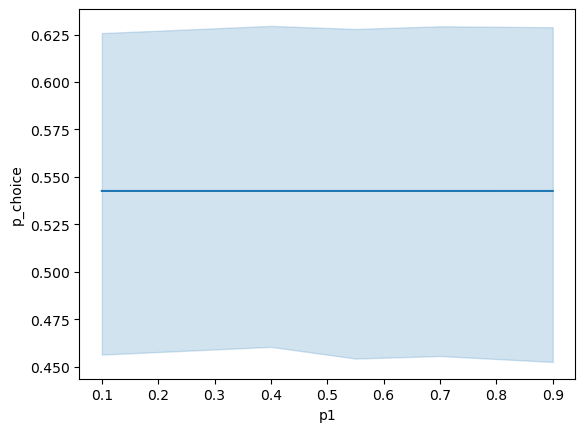

In [78]:
# pred = model.predict(paradigm, parameters)

g = sns.lineplot(x='p1', y='p_choice', data=pred, legend=True)
# g = sns.lineplot(x='log(ev2/ev1)', y='p_choice', data=pred, hue='p2', legend=True)
# g.add_legend()

In [93]:
with model.prediction_model:
    model_inputs = model.get_model_inputs(parameters)

In [94]:
model_inputs

{'n1_evidence_mu': log(n1),
 'p1_evidence_mu': Log.0,
 'n1_prior_sd': 0.25,
 'n1_evidence_sd': 0.25,
 'n1_prior_mu': mean,
 'p1_evidence_sd': 0.01,
 'p1_prior_mu': 0.0,
 'p1_prior_sd': 25.0,
 'n2_evidence_mu': log(n2),
 'p2_evidence_mu': Log.0,
 'n2_prior_sd': 0.25,
 'n2_evidence_sd': 0.25,
 'n2_prior_mu': mean,
 'p2_evidence_sd': 0.01,
 'p2_prior_mu': 0.0,
 'p2_prior_sd': 25.0}

In [70]:
from bauer.utils.bayes import get_posterior
ix = 0
n1_hat_mean, n1_hat_sd = get_posterior(model_inputs[f'n{ix+1}_evidence_mu'], model_inputs[f'n{ix+1}_evidence_sd'], model_inputs[f'n{ix+1}_prior_mu'], model_inputs[f'n{ix+1}_prior_sd'])

In [72]:
n1_hat_mean.eval()

array([0.09933057, 0.76581824, 1.15568854, 1.43230591, 1.64686702,
       1.82217621, 1.97039802, 2.09879359, 2.21204651, 2.31335469,
       2.4049991 , 2.48866388, 2.56562803, 2.63688569, 2.70322499,
       2.76528126, 2.82357417, 2.87853418, 2.93052189, 2.97984237,
       3.02675599, 3.07148677, 3.11422885, 3.15515156, 3.19440348,
       3.2321157 , 3.26840448, 3.30337337, 3.33711502, 0.09933057,
       0.76581824, 1.15568854, 1.43230591, 1.64686702, 1.82217621,
       1.97039802, 2.09879359, 2.21204651, 2.31335469, 2.4049991 ,
       2.48866388, 2.56562803, 2.63688569, 2.70322499, 2.76528126,
       2.82357417, 2.87853418, 2.93052189, 2.97984237, 3.02675599,
       3.07148677, 3.11422885, 3.15515156, 3.19440348, 3.2321157 ,
       3.26840448, 3.30337337, 3.33711502, 0.09933057, 0.76581824,
       1.15568854, 1.43230591, 1.64686702, 1.82217621, 1.97039802,
       2.09879359, 2.21204651, 2.31335469, 2.4049991 , 2.48866388,
       2.56562803, 2.63688569, 2.70322499, 2.76528126, 2.82357

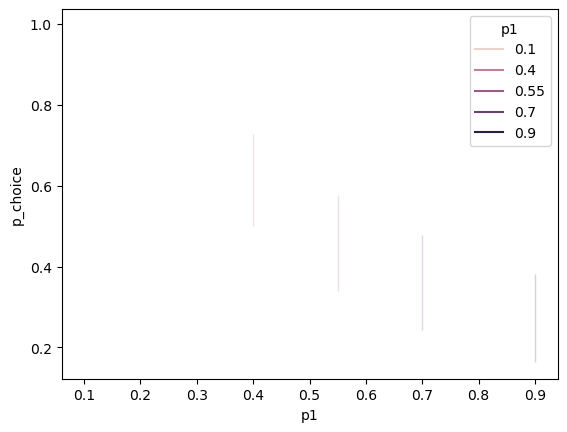

In [17]:
pred = model.predict(paradigm, parameters)

g = sns.lineplot(x='p1', y='p_choice', data=pred, hue='p1', legend=True)
# g = sns.lineplot(x='log(ev2/ev1)', y='p_choice', data=pred, hue='p2', legend=True)
# g.add_legend()

In [5]:
data = model.simulate(paradigm, parameters, n_samples=1)

In [6]:
data['choice'] = data['simulated_choice']

In [7]:
model.build_estimation_model(data=data, hierarchical=False)

In [8]:
idata = model.sample(100, 100)

Only 100 samples in chain.
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [magnitude_evidence_sd_untransformed, magnitude_prior_sd_untransformed, probability_evidence_sd_untransformed, probability_prior_sd_untransformed, probability_prior_mu]


Sampling 4 chains for 100 tune and 100 draw iterations (400 + 400 draws total) took 47 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [9]:
ppc = model.ppc(data, idata=idata)

Sampling: [ll_bernoulli, magnitude_evidence_sd_mu_untransformed, magnitude_evidence_sd_offset, magnitude_evidence_sd_sd, magnitude_prior_sd_mu_untransformed, magnitude_prior_sd_offset, magnitude_prior_sd_sd, probability_evidence_sd_mu_untransformed, probability_evidence_sd_offset, probability_evidence_sd_sd, probability_prior_mu_mu, probability_prior_mu_offset, probability_prior_mu_sd, probability_prior_sd_mu_untransformed, probability_prior_sd_offset, probability_prior_sd_sd]


In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az

def summarize_ppc(ppc, groupby=None):

    if groupby is not None:
        ppc = ppc.groupby(groupby).mean()

    e = ppc.mean(1).to_frame('p_predicted')
    hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,
                       columns=['hdi025', 'hdi975'])

    return pd.concat((e, hdi), axis=1)

def plot_prediction(data, x, color, y='p_predicted', alpha=.5, **kwargs):

    data = data[~data['hdi025'].isnull()]
    data = data.sort_values(x)

    plt.fill_between(data[x], data['hdi025'],
                     data['hdi975'], color=color, alpha=alpha)
    plt.plot(data[x], data[y], color=color)


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_19023/3579196882.py:11: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,


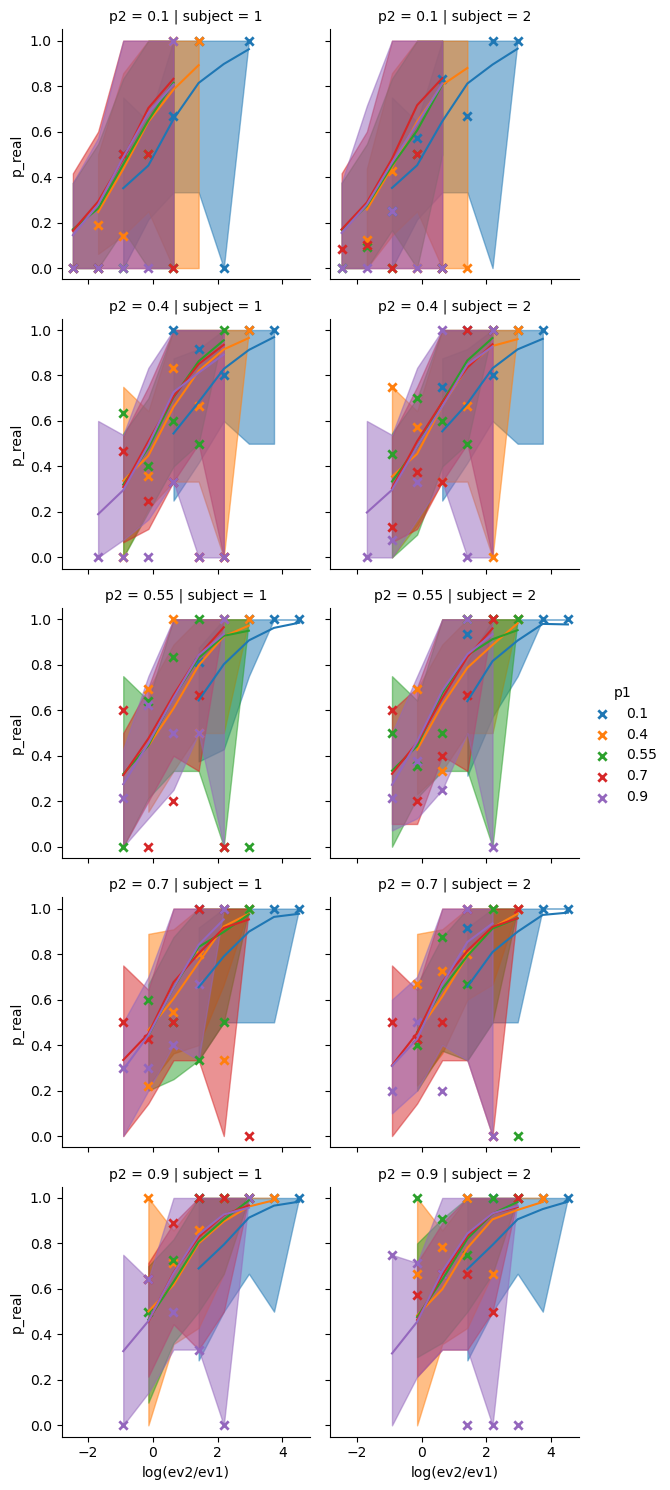

In [19]:
ppc_stats = summarize_ppc(ppc, groupby=['subject', 'p1', 'p2', 'log(ev2/ev1)'])
ppc_stats = ppc_stats.join(data.groupby(['subject', 'p1', 'p2', 'log(ev2/ev1)']).mean()['choice'].to_frame('p_real'))

g = sns.FacetGrid(ppc_stats.reset_index(), col='subject', row='p2', hue='p1')
g.map_dataframe(plot_prediction, x='log(ev2/ev1)')
g.map(plt.scatter, 'log(ev2/ev1)', 'p_real', marker='x', lw=2)
g.add_legend()

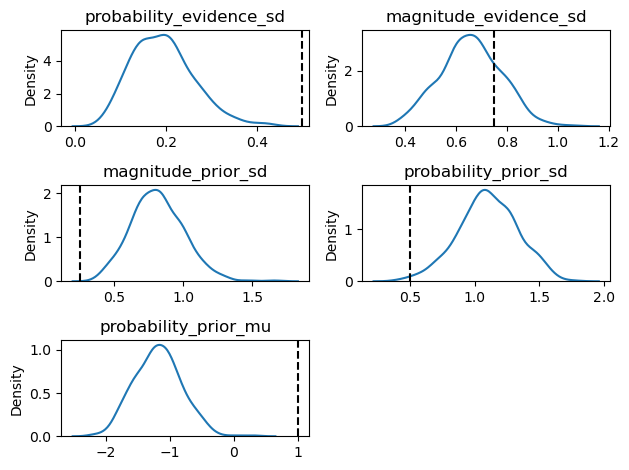

In [18]:
for i, key in enumerate(parameters):
    plt.subplot(3, 2, i+1)
    sns.kdeplot(idata.posterior[key].to_dataframe(), legend=False)
    plt.axvline(parameters[key], color='k', ls='--')
    plt.title(key)

plt.tight_layout()

$log n1 \sim \mathcal{N}(\log n1, \sigma_1)$
$log n2 \sim \mathcal{N}(\log n2, \sigma_2)$

$p = \frac{n1}{n1+n2} = \frac{\mathcal{N}(\log n1, \sigma_1)}{\mathcal{N}(\log n1, \sigma_1) + \mathcal{N}(\log n2, \sigma_2)}$


$1 - p = \frac{n2}{n1+n2}$

$\frac{p}{1-p} = \frac{n1}{n1+n2} \frac{n1+n2}{n2} = \frac{n1}{n2}$

$\log \frac{n1}{n2} = \log n1 - \log n2 ={\mathcal{N}(\log n1, \sigma_1) + \mathcal{N}(\log n2, \sigma_2)} $


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_36170/200226038.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x)


<Axes: ylabel='Density'>

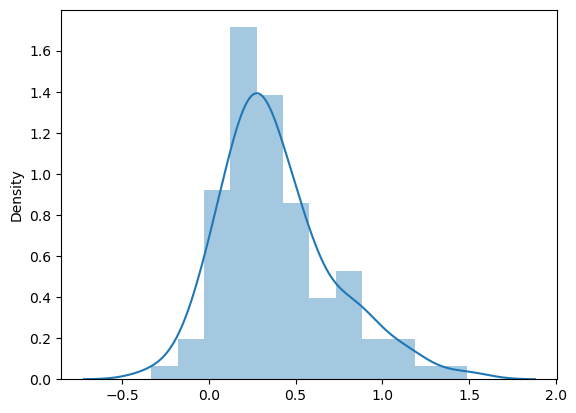

In [110]:
import scipy.stats as ss

n1 = ss.norm(np.log(5), 1)
n2 = ss.norm(np.log(15), 1)

x = n1.rvs(100) / (n1.rvs(100)  + n2.rvs(100))

sns.distplot(x)